### pyAPES_MLM: Multi-layer soil-vegetation-atmosphere transfer model

Demo how to:
1. Set-up the model
1. Run the model
1. Retrieve the results using xarray

In [8]:
# setting path
import sys
#sys.path.append('c:\\Repositories\\pyAPES_main')
import os
from dotenv import load_dotenv

load_dotenv()
pyAPES_main_folder = os.getenv('pyAPES_main_folder')

sys.path.append(pyAPES_main_folder)
#print(sys.path)

# force iPython re-import modules at each call
%matplotlib qt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import modules

In [9]:
# function to read forcing data. See 'forcing/forcing_info.txt' for model forcing variable names and units!
from pyAPES.utils.iotools import read_forcing

# import the multi-layer model (mlm) driver
from pyAPES.pyAPES_MLM import driver

eps = 1e-16

### Read model parameter dictionaries

- mlm setup (parameterization, forcing file & run info) defined in: pyAPES.models.mlm_parameters
- output variables & logger configuration defined in: pyAPES.models.mlm_outputs. This is read by driver

In [10]:
# import parameter dictionaries
from pyAPES.parameters.mlm_parameters_FI_Ran import gpara, cpara, spara # model configuration, canopy parameters, soil parameters

### Read forcing data and compile input for driver

- forcing is read into pd.DataFrame. Units must be correct!
- create parameter dictionary and provide it to driver

#### Local modification to forc_filename

forc_filename should lead to parent folder where forcing folder is

In [11]:
forcing_file_path = '../'+gpara['forc_filename']

In [12]:
forcing = read_forcing(
    forcing_file=forcing_file_path,
    start_time=gpara['start_time'],
    end_time=gpara['end_time'],
    dt=gpara['dt']
)

params = {
    'general': gpara,   # model configuration
    'canopy': cpara,    # planttype, micromet, canopy, bottomlayer parameters
    'soil': spara,      # soil heat and water flow parameters
    'forcing': forcing  # forging data
}

In [14]:

# Interactive plot of forcing variables - useful for checking units and data quality
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline

def plot_forcing_var(variable):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(forcing.index, forcing[variable], lw=0.8)
    ax.set_title(variable)
    ax.set_xlabel('Time')
    ax.tick_params(axis='x', labelrotation=20)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_forcing_var,
    variable=widgets.Dropdown(options=list(forcing.columns), description='Variable:')
)


interactive(children=(Dropdown(description='Variable:', options=('doy', 'Prec', 'P', 'Tair', 'Tdaily', 'U', 'U…

<function __main__.plot_forcing_var(variable)>

In [6]:
gpara

{'dt': 1800.0,
 'start_time': '2022-06-01',
 'end_time': '2022-06-15',
 'start_doy': 152,
 'forc_filename': 'forcing/FI-Ran/FI-Ran_forcing_2022_2025.dat',
 'results_directory': 'results/'}

### Run the model

In [13]:
resultfile, Model = driver(parameters=params,
                           create_ncf=True,
                           result_file= 'testrun.nc'
                          )

# alternative (for testing over short periods) is to return resuts in dictionary 'results'
# results, Model = driver(parameters=params,
#                         create_ncf=False,
#                         result_file=None
#                          )

INFO pyAPES.pyAPES_MLM driver pyAPES_MLM simulation started. Number of simulations: 1
INFO pyAPES.soil.water __init__ Water balance in soil solved using: RICHARDS EQUATION & no lateral drainage
INFO pyAPES.soil.heat __init__ Soil heat balance solved.
INFO pyAPES.canopy.mlm_canopy __init__ Eflow: True, WMA: False, Ebal: True
INFO pyAPES.microclimate.radiation __init__ Shortwave radiation model: ZHAOQUALLS
INFO pyAPES.microclimate.radiation __init__ Longwave radiation model: ZHAOQUALLS
c:\\Repositories\\pyAPES_main\pyAPES\bottomlayer\organiclayer.py:1217: RuntimeWarning: invalid value encountered in scalar power
  Psi = -1e-2 / alfa*(s**(1.0 / m) - 1.0)**(1.0 / n)  # m
INFO pyAPES.canopy.forestfloor __init__ Forestfloor has 3 bottomlayer types
INFO pyAPES.utils.iotools save_parameters_yaml Parameters saved to: c:\Repositories\pyAPES_main\input_parameters\testrun.yml
INFO pyAPES.pyAPES_MLM driver Running simulation number (start time 2026-05-08 15:34): 0
INFO pyAPES.pyAPES_MLM run Running

0%.. 10%.. 20%.. 

c:\\Repositories\\pyAPES_main\pyAPES\leaf\photo.py:381: RuntimeWarning: overflow encountered in exp
  DENOM = 1.0 + np.exp((T*Sd_v - Hd_v) * inv_T_GAS_CONSTANT)
c:\\Repositories\\pyAPES_main\pyAPES\leaf\photo.py:390: RuntimeWarning: overflow encountered in exp
  DENOM = 1.0 + np.exp((T*Sd_j - Hd_j) * inv_T_GAS_CONSTANT)


30%.. 40%.. 50%.. 60%.. 70%.. 80%.. 90%.. 

INFO pyAPES.pyAPES_MLM run Finished simulation 0, running time 135.01 seconds
INFO pyAPES.pyAPES_MLM driver Running time 135.02 seconds


100%


INFO pyAPES.pyAPES_MLM driver Ready! Results are in: c:\\Repositories\\pyAPES_main/results/testrun.nc


### Model run completed and results are in NetCDF-file.

### Read results using xarray
- we use function 'read_results' from pyAPES.utils.utils

- see https://docs.xarray.dev/en/stable/



In [17]:
from pyAPES.utils.iotools import read_results
import matplotlib.pyplot as plt

# read simulation restuls to xarray dataset
results = read_results(resultfile)

c:\\Repositories\\pyAPES_main/results/testrun.nc


### Print resuts metadata:

Output variables are those defined at pyAPES.parameters.mlm_outputs'. Each variable contains one or several of following dimensions:

- date --> time dimension
- simulation --> simulation number. If there is only one, remember that it has index 0!
- canopy --> canopy and air layers. Index is 0 at ground and increases upwards
- planttype --> planttypes defined in mlm_parameters. Index follows the order in dict cpara['planttypes']) 
- soil -> soil layers. Index 0 is at the top and increases downwards (nr soil layers, 0 at top)
- groundtype --> groundtypes at forestfloor. Defined in mlm_parameters. Index follows the order in dict: cpara['forestfloor']['bottom_layer_types']


In [ ]:
print(results)

# print list of all variables:
#vars = list(results.data_vars)
#for v in vars:
#    print(v)

### Plot some model results

In [18]:
sim = 0  # in this demo, we have only one simulation (i.e. only one parameter set was used)

# grid variables for plotting
t = results.date  # time
zc = results.canopy_z  # height above ground [m]
zs = results.soil_z  # depth of soil; shown negative [m]

### Soil temperature and moisture

- computed using pyAPES.soil - package submodels 'Water' and 'Heat'
- model state at end of simulation is in: Model.soil.heat & Model.soil.water

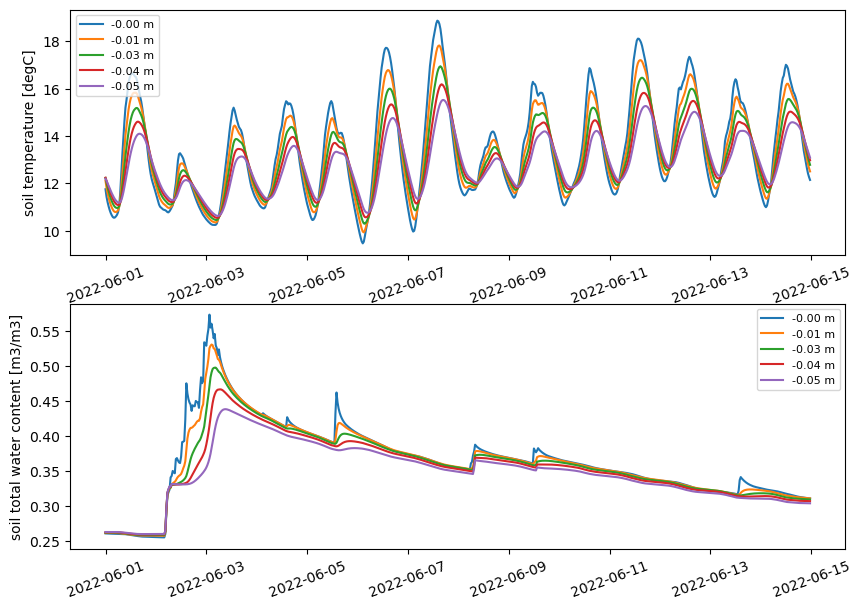

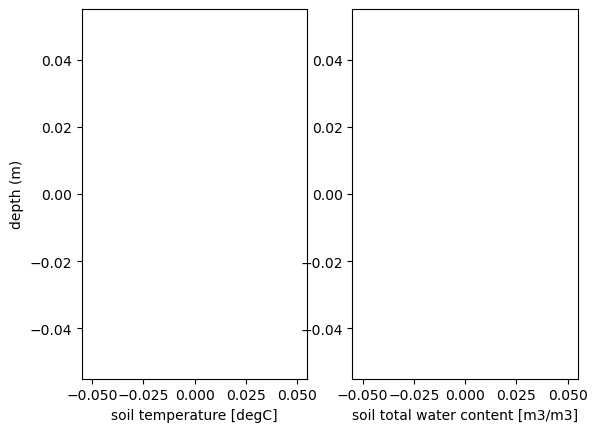

In [19]:
import numpy as np
var = ['soil_temperature', 'soil_volumetric_water_content']

lyrs = [0, 1, 2, 3, 4] # five top layers
#depths = np.array2string(np.asarray(zs[lyrs]), precision=1, separator=', ')
depths = ['{:.2f} m'.format(k) for k in zs[lyrs]]

fig, ax = plt.subplots(2, 1, figsize=(10,7))

k = 0
for v in var:
    ax[k].plot(t, results[v][:,sim,lyrs], label=depths)
    ax[k].set_ylabel(results[v].attrs['units'])
    ax[k].tick_params(axis='x', labelrotation = 20)
    ax[k].legend(fontsize=8)
    k += 1

# vertical profile at last timestep
fig, ax = plt.subplots(1, 2) #figsize=(10,5))

k = 0
for v in var:
    ax[k].plot(results[v][-1,sim,:], zs)
    ax[k].set_xlabel(results[v].attrs['units'])
    ax[0].set_ylabel('depth (m)')
    k += 1

### Ecosystem-scale fluxes

- ecosystem - atm. fluxes represent the integrated sinks / sources in soil (soil-module), forestfloor (bottomlayer-module) and vegetation (planttype&canopy -modules)
- comparable to ecosystem - atmosphere exchange
- affected by current model forcing and sub-model instance state (e.g. Planttype and Canopy LAI, phenology, soil temperature, moisture etc.)


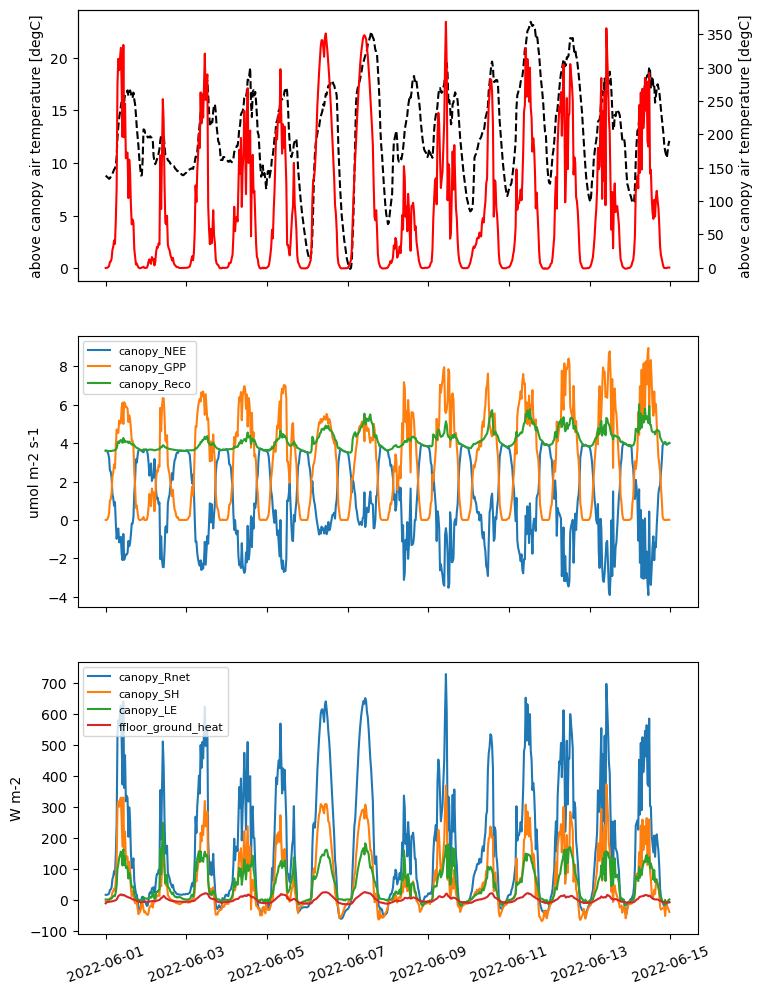

In [20]:

var = ['forcing_air_temperature', 'forcing_par', 'canopy_NEE', 'canopy_GPP', 
       'canopy_Reco', 'canopy_Rnet', 'canopy_SH', 'canopy_LE', 'ffloor_ground_heat']

fig, ax = plt.subplots(3, 1, figsize=(8,12), sharex=True)

# temperature & par
ax[0].plot(t, results[var[0]][:,sim], 'k--', label=var[0])
ax[0].set_ylabel(results[var[0]].attrs['units'])
ax[0].tick_params(axis='x', labelrotation = 20)
axb = ax[0].twinx()

axb.plot(t, results[var[1]][:,sim], 'r-', label=var[1]) # Par
axb.set_ylabel(results[var[0]].attrs['units'])

# CO2 fluxes
for v in var[2:5]:
    ax[1].plot(t, results[v][:,sim], label=v)

ax[1].set_ylabel('umol m-2 s-1')
ax[1].tick_params(axis='x', labelrotation = 20)
ax[1].legend(fontsize=8)

# energy fluxes
for v in var[5:]:
    ax[2].plot(t, results[v][:,sim], label=v)

ax[2].set_ylabel('W m-2')
ax[2].tick_params(axis='x', labelrotation = 20)
ax[2].legend(fontsize=8)



### Ecosystem radiation balance

- net radiation (Rnet) is the sum of net shortwave (SWnet = incoming - reflected) and net longwave (LWnet = incoming - emitted) radiation at canopy top
- computed via models in pyAPES.microclimate.radiation, called iteratively from pyAPES.canopy.mlm_canopy to account for canopy structure and leaf & forest floor temperature
- ecosystem albedo can be computed from radiation profiles at uppermost grid point

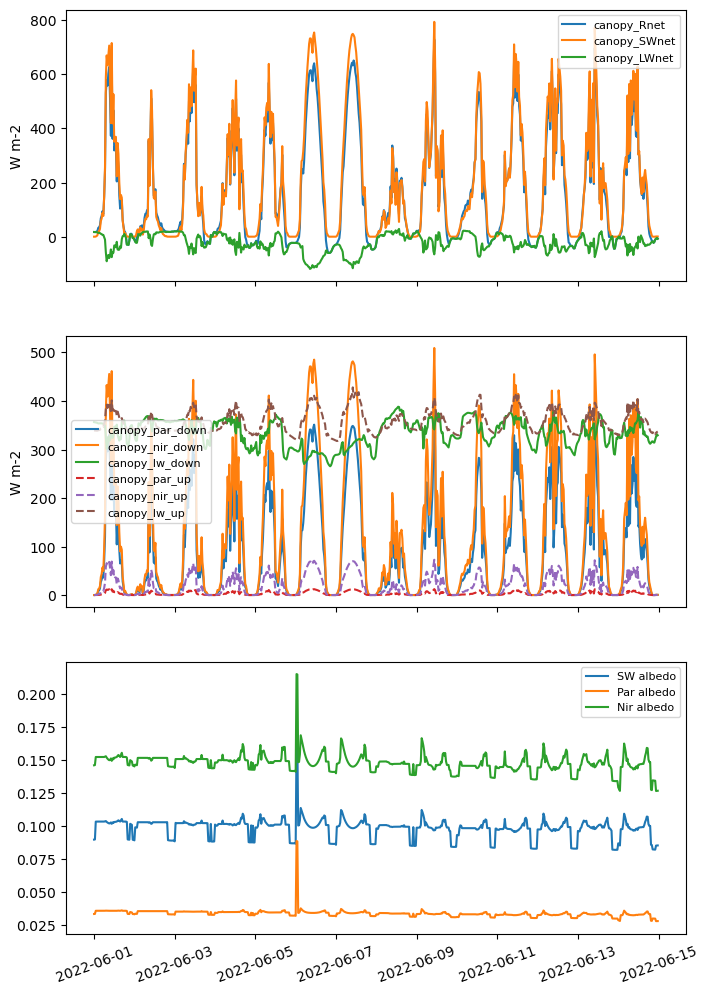

In [21]:
# net radiation components at canopy top
var = ['canopy_Rnet','canopy_SWnet', 'canopy_LWnet']
profs = ['canopy_par_down', 'canopy_par_up', 'canopy_nir_down','canopy_nir_up','canopy_lw_down','canopy_lw_up']

fig, ax = plt.subplots(3, 1, figsize=(8,12), sharex=True)

for v in var:
    ax[0].plot(t, results[v][:, sim], label=v)
ax[0].set_ylabel('W m-2')
ax[0].tick_params(axis='x', labelrotation = 20)
ax[0].legend(fontsize=8)    

# lets plot also partitioning of canopy_SWnet and canopy_LWnet.
# -1 is the index of uppermost gridpoint

for v in ['canopy_par_down', 'canopy_nir_down','canopy_lw_down']: # downward
    ax[1].plot(t, results[v][:,sim,-1], '-', label=v)
for v in ['canopy_par_up', 'canopy_nir_up','canopy_lw_up']: # upward
    ax[1].plot(t, results[v][:,sim,-1], '--', label=v)
ax[1].set_ylabel('W m-2')
ax[1].tick_params(axis='x', labelrotation = 20)
ax[1].legend(fontsize=8)

# canopy albedo
eps = 1e-16

# fraction of par on total SW
f_par = results['canopy_par_down'][:,sim,-1] / (results['canopy_par_down'][:,sim,-1] + results['canopy_nir_down'][:,sim,-1] + eps)

alb_par = results['canopy_par_up'][:,sim,-1] / (results['canopy_par_down'][:,sim,-1] + eps)
alb_nir = results['canopy_nir_up'][:,sim,-1] / (results['canopy_nir_down'][:,sim,-1] + eps)
alb_sw = f_par * alb_par + (1 - f_par) * alb_nir
alb_sw = np.maximum(0, np.minimum(1.0, alb_sw))

ax[2].plot(t, alb_sw, '-', label='SW albedo')
ax[2].plot(t, alb_par, '-', label='Par albedo')
ax[2].plot(t, alb_nir, '-', label='Nir albedo')

ax[2].tick_params(axis='x', labelrotation = 20)
ax[2].legend(fontsize=8)

### Microclimatic gradients within the canopy

- sub-models pyAPES.microclimate.Micromet & pyAPES.radiation.Radiation
- mean wind speed & friction velocity (momentum flux) profiles depend on momentum absorption in the canopy, which is proportional to leaf-area density (*lad*) profile. Canopy *lad* is sum of *lad* of each PlantType instance
- SW absorption depends on *lad* and leaf optical properties
- air-space scalar profiles (*T*, *H2O* & *CO2*) in steady-state with respective sink/source profile using 1st-order closure (K-theory)

Let's compute average June profiles for daytime hours 10:00 -- 16:00 under conditions when canopy is dry


In [22]:
results[v]

<xarray.DataArray 'canopy_lw_up' (date: 673, simulation: 1, canopy: 101)> Size: 272kB
[67973 values with dtype=float32]
Coordinates:
  * date        (date) datetime64[ns] 5kB 2022-06-01 ... 2022-06-15
  * simulation  (simulation) int64 8B 0
  * canopy      (canopy) float32 404B 0.0 0.25 0.5 0.75 ... 24.5 24.75 25.0
Attributes:
    units:    upward LW [W m-2]

In [ ]:
results['canopy_interception_storage'][:, 0] < 1e-13

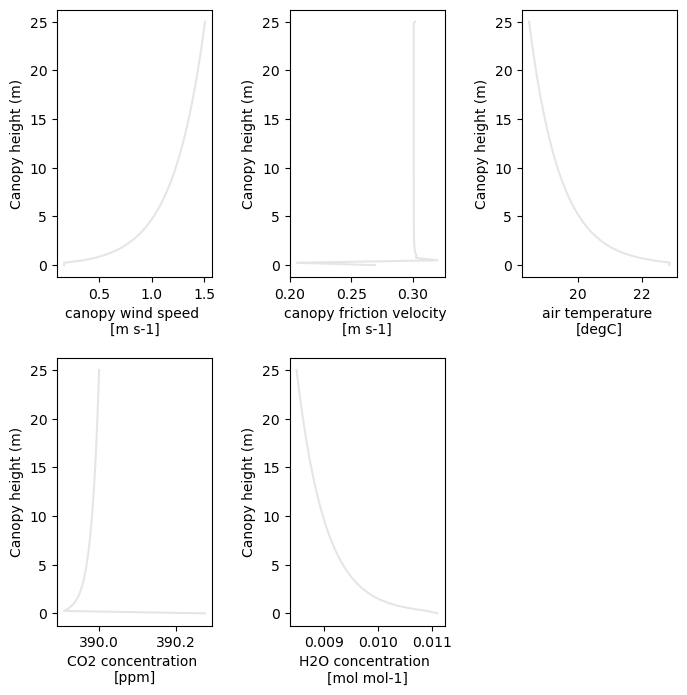

In [23]:

ix = np.where((results.date.dt.hour>=10) & (results.date.dt.hour<=16) & (results['canopy_interception_storage'] <= eps))

rad = ['canopy_par']
mmet = ['canopy_wind_speed', 'canopy_friction_velocity', 'canopy_temperature', 'canopy_co2', 'canopy_h2o']

fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(8,8))
fig.subplots_adjust(hspace=0.3, wspace=0.5)
axs = axs.flatten()
axs[-1].remove()
n = 1
# Define vertical axis
z = results['canopy_z'].values
# Select conditions when canopy is dry and
# select time between 10:00-16:00 each day in June.
# We define canopy as dry if canopy interception storage is negligible
results_sel = results[mmet]
results_sel = results.sel(date=((results.date.dt.month==6).values &
                                (results.date.dt.hour >= 10).values &
                                (results.date.dt.hour <= 16).values &
                                 (results['canopy_interception_storage'][:, 0] < eps).values))

#results_sel = results_sel.sel(date=dry_canopy_mask)
for v in mmet:
    plt.subplot(2,3,n)
    
    x = results_sel[v][:, sim, :]
    xm = np.mean(x, axis=0)
    plt.plot(xm, z, 'k', alpha=0.1)
    unit_starts = results[v].attrs['units'].find('[')
    plt.xlabel(results[v].attrs['units'][:unit_starts] + '\n' + results[v].attrs['units'][unit_starts:]) #linebreak between unit and label text
    plt.ylabel('Canopy height (m)')
    n += 1

In [ ]:
results.close()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plot plant-type specific leaf area densities (LAD profiles)
z_canopy = np.linspace(0, cpara['grid']['zmax'], cpara['grid']['Nlayers'])

fig, ax = plt.subplots(figsize=(4, 6))

for name, pt in cpara['planttypes'].items():
    lad = pt['lad']
    LAImax = pt['LAImax']
    # lad is normalized (integral=1), scale to actual LAImax
    ax.plot(lad * LAImax, z_canopy, label=f"{name} (LAI={LAImax})")

ax.set_xlabel('Leaf area density (m² m⁻³)')
ax.set_ylabel('Height (m)')
ax.set_title('Plant-type LAD profiles')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
